# Supervised Learning with `Scikit-Learn`

####  List of exercises
>  - **Exercise 1 (Ungraded):** UCI ML hand-written Digits Dataset.
>  - **Exercise 2:** Handwritten Character Recognition Using the MNIST Dataset (100).

## A Classifier Comparison via Decision Boundaries with Scikit-Learn

A comparison of several classifiers in `scikit-learn` on synthetic datasets. The goal of this comparison is to illustrate the nature of decision boundaries of different classifiers. This should be taken with a grain of salt, as the intuition conveyed by these examples does not necessarily carry over to real datasets.

Particularly in high-dimensional spaces, data can more easily be separated linearly and the simplicity of classifiers such as naive Bayes and linear SVMs might lead to better generalization than is achieved by other classifiers.

The plots show training points in solid colors and testing points semi-transparent. The lower right text in each decision boundary plot  shows the classification accuracy on the test set.

In [0]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
# Additions: GT Jemwa: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
    "Histogram GBC",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    HistGradientBoostingClassifier(random_state=42),
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)

# linearly separable
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

# xor
rng = np.random.RandomState(0)
X = rng.randn(200, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
xor_data = (X,y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
    xor_data,
]

figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

<br>
<div class="alert alert-success">
<b style="font-size: 25px">Exercise 1: UCI ML hand-written Digits Dataset</b>
</div>

### Objective:
Train a logistic regression classifier to recognize handwritten digits (0–9) using the UCI ML dataset of 8x8 grayscale images and evaluate its performance

### Dataset: 
Alpaydin, E. & Kaynak, C. (1998). Optical Recognition of Handwritten Digits. UCI Machine Learning Repository. https://doi.org/10.24432/C50P49.

### Instructions
0. Load libraries
1. Load digits using `load_digits` from `sklearn.datasets`
2. Perform an initial data understanding

   2.1 Inspect Dataset Structure
   - Check number of rows and columns
   - Understand feature types (categorical, numerical, text, image, etc.)
   - Identify target variable (if supervised)
   
   2.2 Preview the Data
   - Use `head()`, `sample()`, or a few plots to understand data layout
   - Look for patterns, strange values, or formatting issues
   - If images, plot 
     
   2.3 Check for Missing Values
   - Use `isnull().sum()` (for tabular data)
   - Determine which features need imputation or exclusion
     
   2.4 Check for Duplicates
   - Identify and optionally drop duplicate rows
     
   2.5 Understand Class Distributions (for classification)
   - Use `value_counts()` to check if classes are balanced
   - Plan for resampling if imbalance is severe
     
   2.6 Understand Feature Distributions
   - Plot histograms or value counts to identify skewed or unusual distributions
     
   2.7 Check Data Types
   - Ensure types (e.g., integer, float, object) match expectations
   - Convert categorical/text features if needed
     
   2.8 Validate Labels
   - Ensure labels are within expected range (0–9 for digits)
   - Check for typos or inconsistencies in categorical labels
     
   2.9 Perform Sanity Checks 
   - Confirm number of classes, image shapes, label formats, etc.
   - Look for corrupted, empty, or malformed entries
     
4. If the task is to solve a binary/multiclass classification problem, encode the target variable as needed
   
6. Design the ML pipeline
   
8. Train the classification model using the train data
   
10. Evaluate model performance using the test data

   7.1 Create a confusion matrix for classification problem
   
   7.2 Use ROC curve and AUC metrics to explore model performance for each digit

<br>
<div class="alert alert-success">
<b style="font-size: 25px">Your Solution Here</b>
</div>

In [0]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, auc, precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline

Matplotlib is building the font cache; this may take a moment.


Shape: (1797, 64)
Feature types: float64
Target variable: int64


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0.0,0.0,3.0,15.0,13.0,2.0,0.0,0.0,0.0,0.0,10.0,16.0,12.0,13.0,0.0,0.0,0.0,0.0,13.0,13.0,9.0,14.0,0.0,0.0,0.0,0.0,6.0,15.0,15.0,11.0,0.0,0.0,0.0,0.0,4.0,16.0,14.0,1.0,0.0,0.0,0.0,0.0,11.0,14.0,15.0,5.0,0.0,0.0,0.0,0.0,9.0,10.0,14.0,9.0,0.0,0.0,0.0,0.0,4.0,16.0,15.0,2.0,0.0,0.0
0.0,0.0,0.0,8.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,14.0,0.0,0.0,0.0,0.0,0.0,3.0,16.0,7.0,0.0,0.0,0.0,0.0,0.0,6.0,16.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,16.0,16.0,13.0,5.0,0.0,0.0,0.0,15.0,16.0,9.0,9.0,14.0,0.0,0.0,0.0,3.0,14.0,9.0,2.0,16.0,2.0,0.0,0.0,0.0,7.0,15.0,16.0,11.0,0.0
0.0,0.0,1.0,12.0,10.0,3.0,0.0,0.0,0.0,0.0,7.0,16.0,16.0,7.0,0.0,0.0,0.0,0.0,12.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,14.0,16.0,16.0,2.0,0.0,0.0,0.0,1.0,15.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,15.0,16.0,15.0,2.0,0.0,0.0,0.0,0.0,11.0,16.0,16.0,8.0,0.0,0.0,0.0,0.0,1.0,7.0,12.0,10.0,0.0,0.0
0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
0.0,0.0,4.0,6.0,11.0,14.0,6.0,0.0,0.0,4.0,16.0,16.0,12.0,16.0,7.0,0.0,0.0,6.0,16.0,2.0,1.0,16.0,3.0,0.0,0.0,5.0,16.0,0.0,5.0,14.0,0.0,0.0,0.0,0.0,2.0,0.0,11.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,4.0,0.0,0.0,0.0,0.0,0.0,8.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,12.0,0.0,0.0,0.0


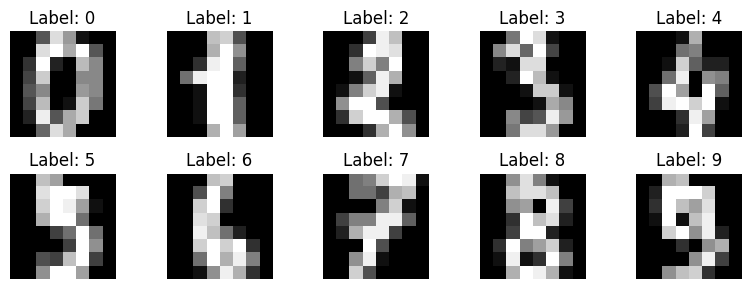

Missing values: 0
Duplicate rows: 0


3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
dtype: int64

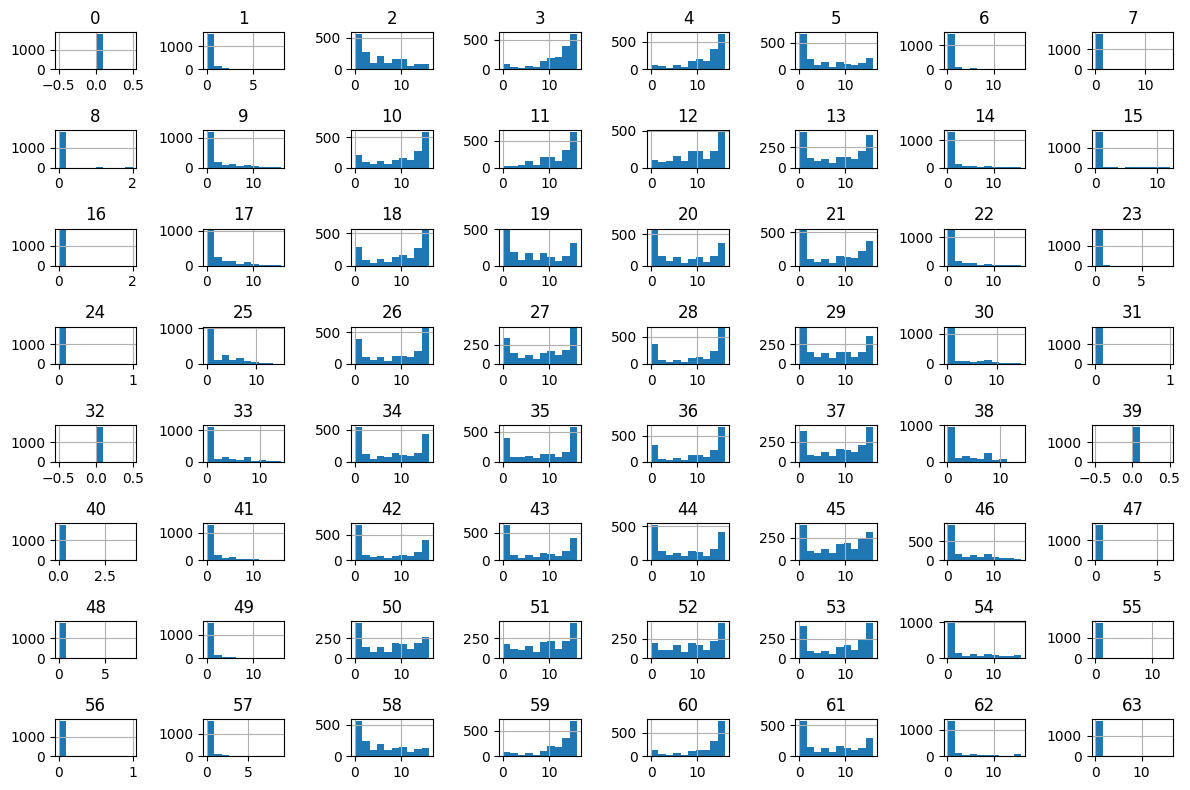

0     float64
1     float64
2     float64
3     float64
4     float64
       ...   
59    float64
60    float64
61    float64
62    float64
63    float64
Length: 64, dtype: object

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Label range: 0 - 9
Number of classes: 10
Image shape: (8, 8)


/databricks/python/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.9703703703703703
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.93      0.96        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.89      0.98      0.93        43
           9       0.95      0.97      0.96        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



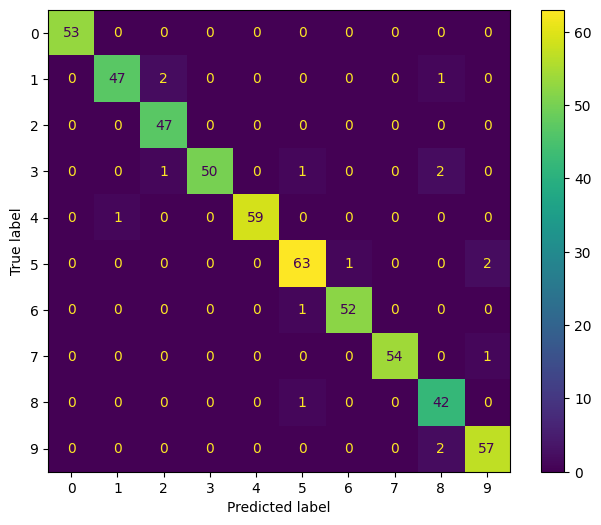

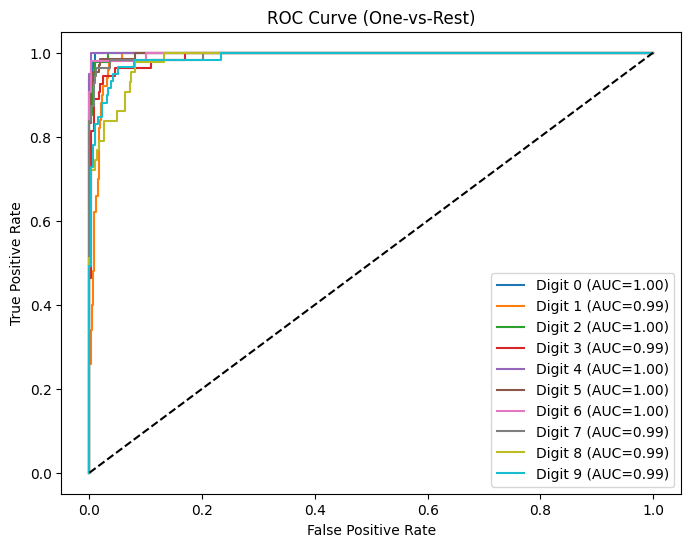

In [0]:
# Data understanding

# Load digits data
digits = load_digits()
X = digits.data
y = digits.target

# Inspect dataset structure
print("Shape:", X.shape)
print("Feature types:", X.dtype)
print("Target variable:", y.dtype)

# Preview the data
df = pd.DataFrame(X)
display(df.head())
display(df.sample(5))

# Plot a few images
fig, axs = plt.subplots(2, 5, figsize=(8, 3))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Class distribution
display(pd.Series(y).value_counts())

# Feature distributions
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Check data types
display(df.dtypes)

# Validate labels
print("Unique labels:", np.unique(y))
print("Label range:", y.min(), "-", y.max())

# Sanity checks
print("Number of classes:", len(np.unique(y)))
print("Image shape:", X[0].reshape(8, 8).shape)

# Encode target variable (already numeric)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Design ML pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='saga', max_iter=1000))
])

# Train model
pipeline.fit(X_train, y_train)

# Evaluate model
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.show()

# ROC curve and AUC for each digit
fig, ax = plt.subplots(figsize=(8, 6))
for digit in np.unique(y):
    y_test_bin = (y_test == digit).astype(int)
    y_score = pipeline.decision_function(X_test)[:, digit] if hasattr(pipeline, "decision_function") else pipeline.predict_proba(X_test)[:, digit]
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'Digit {digit} (AUC={roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('ROC Curve (One-vs-Rest)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()

In [0]:
# Load digits data and target
digits = load_digits()
X = digits.data
y = digits.target

0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0.0,0.0,11.0,15.0,12.0,1.0,0.0,0.0,0.0,0.0,7.0,16.0,16.0,7.0,0.0,0.0,0.0,0.0,12.0,16.0,16.0,16.0,1.0,0.0,0.0,0.0,13.0,16.0,16.0,13.0,2.0,0.0,0.0,0.0,14.0,16.0,16.0,4.0,0.0,0.0,0.0,2.0,16.0,16.0,14.0,0.0,0.0,0.0,0.0,0.0,14.0,16.0,14.0,0.0,0.0,0.0,0.0,0.0,8.0,16.0,13.0,1.0,0.0,0.0
0.0,0.0,7.0,15.0,16.0,12.0,0.0,0.0,0.0,4.0,16.0,11.0,12.0,12.0,0.0,0.0,0.0,2.0,7.0,1.0,13.0,11.0,0.0,0.0,0.0,0.0,0.0,13.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,15.0,16.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,15.0,8.0,0.0,0.0,0.0,5.0,16.0,12.0,15.0,8.0,0.0,0.0,0.0,7.0,16.0,16.0,13.0,2.0,0.0
0.0,0.0,5.0,16.0,5.0,0.0,0.0,0.0,0.0,0.0,12.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,3.0,16.0,9.0,1.0,0.0,0.0,0.0,0.0,7.0,16.0,16.0,16.0,9.0,0.0,0.0,0.0,1.0,16.0,10.0,8.0,16.0,6.0,0.0,0.0,0.0,12.0,14.0,5.0,9.0,13.0,0.0,0.0,0.0,4.0,15.0,15.0,12.0,3.0,0.0
0.0,0.0,5.0,14.0,14.0,8.0,2.0,0.0,0.0,3.0,15.0,3.0,0.0,13.0,8.0,0.0,0.0,5.0,12.0,0.0,2.0,15.0,8.0,0.0,0.0,2.0,15.0,9.0,14.0,14.0,8.0,0.0,0.0,0.0,1.0,3.0,0.0,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,4.0,0.0,0.0,6.0,15.0,2.0,0.0,14.0,1.0,0.0,0.0,1.0,7.0,14.0,12.0,9.0,0.0,0.0
0.0,0.0,2.0,11.0,13.0,4.0,0.0,0.0,0.0,1.0,13.0,7.0,8.0,15.0,0.0,0.0,0.0,6.0,11.0,0.0,5.0,13.0,0.0,0.0,0.0,9.0,7.0,2.0,14.0,14.0,0.0,0.0,0.0,3.0,14.0,15.0,8.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,5.0,0.0,0.0,0.0,11.0,7.0,0.0,10.0,7.0,0.0,0.0,0.0,4.0,10.0,15.0,15.0,3.0,0.0


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0,1797.0
0.0,0.3038397328881469,5.204785754034502,11.835837506956038,11.848080133555927,5.781858653311074,1.3622704507512522,0.1296605453533667,0.005564830272676683,1.9938786867000557,10.382303839732888,11.979410127991097,10.279354479688369,8.175848636616584,1.8464106844741235,0.10795770728992765,0.0027824151363383415,2.6015581524763496,9.903171953255425,6.9927657206455205,7.09794101279911,7.806343906510851,1.788536449638286,0.05008347245409015,0.0011129660545353367,2.4696716750139123,9.091263216471898,8.821368948247079,9.927100723427936,7.55147468002226,2.3177518085698385,0.0022259321090706734,0.0,2.3394546466332775,7.6672231496939345,9.07178631051753,10.301613800779077,8.744017807456872,2.90929326655537,0.0,0.008903728436282694,1.5837506956037841,6.881469115191987,7.228158041179744,7.672231496939343,8.23650528658876,3.456316082359488,0.027267668336115748,0.007234279354479688,0.7045075125208681,7.506956037840846,9.53923205342237,9.416249304396215,8.758486366165831,3.725097384529772,0.20645520311630494,5.564830272676684E-4,0.2793544796883695,5.557595993322204,12.089037284362828,11.80912632164719,6.764051196438508,2.0678909293266554,0.36449638286032277
0.0,0.9071920952507534,4.754826339660731,4.248841848260807,4.28738800696946,5.666417727450907,3.3257751860710005,1.0373828570282286,0.09422155480814322,3.1961604075094567,5.421455625901692,3.977542621880106,4.782680570148732,6.052960025710127,3.5863209359653294,0.8279150446454017,0.062368292960202604,3.576301267463955,5.690766948591139,5.802661720976788,6.17572851629557,6.197321772259614,3.259869701959605,0.43859748599498405,0.03335185696431645,3.1465324629263858,6.19203781578259,5.8829364927303525,6.152092831784637,5.872555577910245,3.686455957466465,0.04714036444139983,0.0,3.480372316561777,6.324687349487986,6.268391184618127,5.933490191906331,5.8706476173710325,3.5372827203489945,0.0,0.14518542852282407,2.981816228071556,6.537954671960845,6.441377552036687,6.259511441960655,5.695526575259536,4.330951227733621,0.30735588747482956,0.20422316602535767,1.7461528647057638,5.644496060205793,5.226947700207952,5.302048471649346,6.031154412119314,4.919406035223906,0.9844009177360414,0.023589892481053584,0.9343017983136351,5.10301936991174,4.374694009948624,4.933947353357587,5.900622711999103,4.090547887420139,1.8601217224980682
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,1.0,10.0,10.0,0.0,0.0,0.0,0.0,0.0,6.0,9.0,7.0,2.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,2.0,5.0,5.0,2.0,0.0,0.0,0.0,0.0,1.0,11.0,10.0,0.0,0.0,0.0
0.0,0.0,4.0,13.0,13.0,4.0,0.0,0.0,0.0,0.0,12.0,13.0,11.0,9.0,0.0,0.0,0.0,1.0,12.0,6.0,6.0,8.0,0.0,0.0,0.0,1.0,11.0,10.0,12.0,7.0,0.0,0.0,0.0,0.0,8.0,10.0,13.0,10.0,1.0,0.0,0.0,0.0,6.0,7.0,8.0,9.0,1.0,0.0,0.0,0.0,8.0,10.0,10.0,10.0,1.0,0.0,0.0,0.0,4.0,13.0,14.0,6.0,0.0,0.0
0.0,0.0,9.0,15.0,15.0,11.0,0.0,0.0,0.0,3.0,15.0,16.0,15.0,14.0,2.0,0.0,0.0,4.0,15.0,12.0,13.0,14.0,3.0,0.0,0.0,4.0,15.0,15.0,16.0,13.0,4.0,0.0,0.0,4.0,14.0,16.0,16.0,14.0,6.0,0.0,0.0,2.0,14.0,14.0,14.0,13.0,7.0,0.0,0.0,0.0,13.0,14.0,15.0,15.0,7.0,0.0,0.0,0.0,10.0,16.0,16.0,12.0,2

Missing values: 0
Duplicate rows: 0


3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
dtype: int64

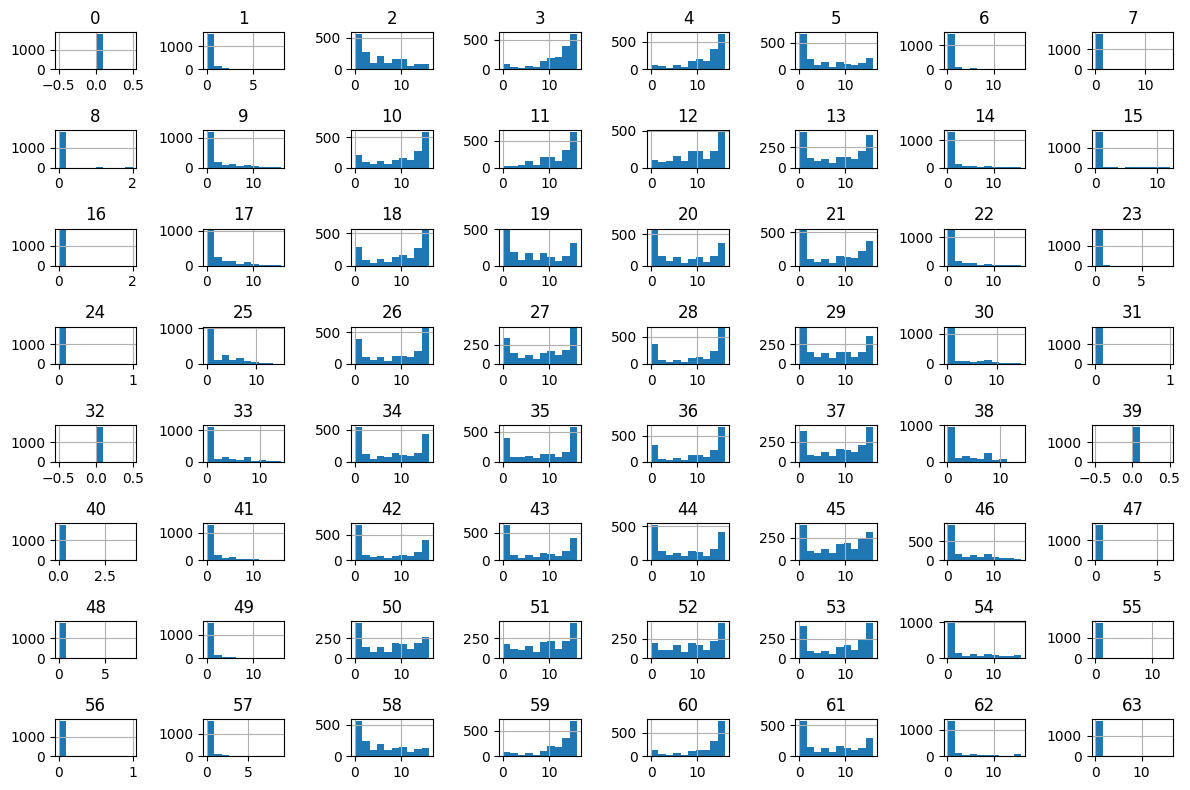

0     float64
1     float64
2     float64
3     float64
4     float64
       ...   
59    float64
60    float64
61    float64
62    float64
63    float64
Length: 64, dtype: object

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Label range: 0 - 9
Number of classes: 10
Image shape: (8, 8)


In [0]:
# Convert to a pandas DF and use the describe(), head(), isnull(), duplicated(), etc.
df = pd.DataFrame(X)
display(df.head())
display(df.sample(5))
display(df.describe())
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
display(pd.Series(y).value_counts())
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()
display(df.dtypes)
print("Unique labels:", np.unique(y))
print("Label range:", y.min(), "-", y.max())
print("Number of classes:", len(np.unique(y)))
print("Image shape:", X[0].reshape(8, 8).shape)

In [0]:
# Check number of rows and columns
display(df.shape)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8627783944346781>, line 2
      1 # Check number of rows and columns
----> 2 display(df.shape)

NameError: name 'df' is not defined

In [0]:
df.head()

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8627783944346782>, line 1
----> 1 df.head()

NameError: name 'df' is not defined

In [0]:
np.any(df.isnull().sum() > 0)

In [0]:
df.describe()

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8627783944346784>, line 1
----> 1 df.describe()

NameError: name 'df' is not defined

In [0]:
# Visualize a few samples  
sample_size = 100  # Must match subplot grid
x_img, _, y_img, _ = train_test_split(X, y, stratify=y, train_size=sample_size)

# Plot
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.imshow(np.reshape(x_img[i], (8, 8)), cmap='gray', interpolation='nearest')
    ax.set_title(f"{y_img[i]}",  fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Inspect dataset structure
display(df.shape)
display(df.dtypes)
print("Feature types:", X.dtype)
print("Target variable:", y.dtype)

# Preview the data
display(df.head())
display(df.sample(5))

# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Class distribution
display(pd.Series(y).value_counts())

# Feature distributions
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Validate labels
print("Unique labels:", np.unique(y))
print("Label range:", y.min(), "-", y.max())
print("Number of classes:", len(np.unique(y)))
print("Image shape:", X[0].reshape(8, 8).shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Design ML pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='saga', max_iter=1000))
])

# Train model
pipeline.fit(X_train, y_train)

# Evaluate model
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.show()

# ROC curve and AUC for each digit
fig, ax = plt.subplots(figsize=(8, 6))
for digit in np.unique(y):
    y_test_bin = (y_test == digit).astype(int)
    y_score = pipeline.decision_function(X_test)[:, digit] if hasattr(pipeline, "decision_function") else pipeline.predict_proba(X_test)[:, digit]
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'Digit {digit} (AUC={roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('ROC Curve (One-vs-Rest)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8627783944346785>, line 3
      1 # Visualize a few samples  
      2 sample_size = 100  # Must match subplot grid
----> 3 x_img, _, y_img, _ = train_test_split(X, y, stratify=y, train_size=sample_size)
      5 # Plot
      6 fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))

NameError: name 'X' is not defined

In [0]:
display(pd.Series(y).value_counts().to_frame('count'))

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8627783944346786>, line 1
----> 1 display(pd.Series(y).value_counts().to_frame('count'))

NameError: name 'y' is not defined

In [0]:
# Class distribution in target variable
np.unique(y, return_counts=True)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8627783944346787>, line 2
      1 # Class distribution in target variable
----> 2 np.unique(y, return_counts=True)

NameError: name 'y' is not defined

In [0]:
# Split into train/test
test_proportion = 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_proportion, random_state=42)

In [0]:
# Design the pipeline

# Standardize features
scaler = StandardScaler()

logreg = LogisticRegression(solver='saga', max_iter=1000)

# Build a Pipeline
clf = Pipeline(steps=[
    ('preprocessor', scaler),
    ('classifier', logreg)
])

# Fit the model
clf.fit(X_train, y_train)

In [0]:
# Evaluation
y_pred = clf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [0]:
fig, ax = plt.subplots(figsize=(8,6))
_ = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)

In [0]:
# Normalized confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalise
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), cmap="viridis")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show(block=False)

In [0]:
# Load digits data
digits = load_digits()
X = digits.data
y = digits.target

# Number of classes
classes = np.unique(y)
n_classes = len(classes)

# Store colors for plots
colors = plt.cm.tab10.colors

# Plot setup
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
# fig_pr, ax_pr = plt.subplots(figsize=(8, 6))

for i, digit in enumerate(classes):
    # Get positive class (digit == i)
    X_pos = X[y == digit]
    y_pos = np.ones(len(X_pos))

    # Get "not digit" (digit != i)
    y_not = y[y != digit]
    X_not = X[y != digit]

    # Preserve class distribution among negative classes
    _, y_counts = np.unique(y_not, return_counts=True)
    y_dist = pd.Series(y_not).value_counts(normalize=True).sort_index()

    # Determine sample size for negative class
    n_neg_samples = len(X_pos) * (n_classes - 1)

    # Sample each class proportionally
    X_neg = []
    y_neg = []
    for cls in y_dist.index:
        cls_indices = np.where(y_not == cls)[0]
        n_samples = int(round(y_dist[cls] * n_neg_samples))
        sampled_indices = np.random.choice(cls_indices, min(n_samples, len(cls_indices)), replace=False)
        X_neg.append(X_not[sampled_indices])
        y_neg.append(np.zeros(len(sampled_indices)))

    X_neg = np.vstack(X_neg)
    y_neg = np.concatenate(y_neg)

    # Combine pos and neg
    X_binary = np.vstack((X_pos, X_neg))
    y_binary = np.concatenate((y_pos, y_neg))

    # Split and train
    X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)
    clf = LogisticRegression(solver='liblinear')
    clf.fit(X_train, y_train)
    y_score = clf.decision_function(X_test)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[i], label=f'Digit {digit} (AUC = {roc_auc:.2f})')

    # Precision-Recall
    # precision, recall, _ = precision_recall_curve(y_test, y_score)
    # ap_score = average_precision_score(y_test, y_score)
    # ax_pr.plot(recall, precision, color=colors[i], label=f'Digit {digit} (AP = {ap_score:.2f})')


# =============================
# ROC Curve Plotting Formatting
# =============================
ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_title('ROC Curve (One-vs-Rest)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend()

# # =================================
# # Precision-Recall Curve Formatting
# # =================================
# ax_pr.set_title('Precision-Recall Curve (One-vs-Rest)')
# ax_pr.set_xlabel('Recall')
# ax_pr.set_ylabel('Precision')
# ax_pr.legend()

# plt.show()

###  When to Use ROC Curve
- ROC curves are most useful when:

   - You have a balanced dataset (positive and negative classes are roughly equally represented).

   - You care equally about false positives and false negatives.

   - You want to visualize the tradeoff between sensitivity (TPR) and fall-out (FPR).

- But ROC curves can be misleading when:

   - The positive class is rare — e.g., 1% fraud detection, cancer detection.

   - The classifier seems to perform well only because of correctly predicting the majority (negative) class.

> In highly imbalanced settings, the FPR stays low just because TN dominates the denominator.

### When to Use Precision-Recall (PR) Curve
- PR curves are more appropriate when:

   - You have imbalanced data (e.g., rare events).

   - The positive class is more important (e.g., detecting fraud, disease, spam).

   - You care more about:

       - Precision: How many of the predicted positives are true?

       - Recall: How many of the actual positives are you catching?

> In other words, if false positives or false negatives are particularly costly, PR curves are a better fit.

<br>
<div class="alert alert-success">
<b style="font-size: 25px;">Exercise 1: End</b>
</div>

<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 2: Handwritten Character Recognition Using the MNIST Dataset </b>
</div>

### Objective:
**Train** a multiple classifiers to recognize handwritten digits (0–9) using the MNIST dataset of 28x28 grayscale images and **evaluate** their performance

### Dataset: 
[The MNIST Database of handwritten digits](http://yann.lecun.com/exdb/mnist/). Yann LeCun, Courant Institute, NYU Corinna Cortes, Google Labs, New York Christopher J.C. Burges, Microsoft Research, Redmond.

### Part 1
#### Instructions: 
1. Load MNIST digits data from `torchvision.datasets` using the code below:
   ```python
   from torchvision.datasets import MNIST
   from torchvision import transforms
    # Train data
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = MNIST(root='./data', train=True, download=True, transform=transform)
    
    # Convert to numpy arrays
    X_train = dataset.data.numpy().reshape(len(dataset), -1)
    y_train = dataset.targets.numpy()
    
    # Test data
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = MNIST(root='./data', train=False, download=True, transform=transform)
    
    # Convert to numpy arrays
    X_test = dataset.data.numpy().reshape(len(dataset), -1)
    y_text = dataset.targets.numpy()

3. Perform an initial data understanding (using the same approach as above).
     
4. If the task is to solve a binary/multiclass classification problem, encode the target variable as needed
   
6. Design the ML pipeline. You can use the **incomplete** starter code below as a starting point.
   ```python
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
    from sklearn.pipeline import make_pipeline
    from sklearn.metrics import confusion_matrix, classification_report
    from sklearn.svm import SVC
    from sklearn.model_selection import cross_validate
    import numpy as np

    # Define models
    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(),
        "Linear SVC": SVC(kernel="linear", C=0.025),
        "HistGBM": HistGradientBoostingClassifier()
    }

    # Evaluate each model in a pipeline
    results = {}
    for name, clf in classifiers.items():
        ...
    ```
   
8. Train the classification models using the train data
   
10. Evaluate model performance using the test data

    6.1 Create a confusion matrix for the classification problem
   
    6.2 Use ROC curves and AUC metrics to explore model performance for each digit and model

### Part 2
#### Instructions:  
1. What digits are most frequently misclassified?  
2. How would performance change with other different models? Why?  
3. What might you do to improve this model?  
4. In using ROC Curves and AUC Metrics to explore model performance on each digit,we are creating a binary classification problem for each digit where one class is all data corresponding to "digit", and the rest are assined to not "digit". The resulting problem becomes imbalanced!! How are we ensuring the class imbalance does not affect model fitting?
5. Visualize a sample of incorrectly classified examples. Would a human have classified these correctly?   
6. Rerun the model fitting and evaluation using 5-fold cross-validation to evaluate model performance (instead of using a single train/test split as above). Use only the train data, and select **only one** of the models for this.
    - Report the average validation score across folds and the standard deviation to quantify uncertainty using `cross_val_score` where the scoring metric is set to `accuracy`.  
    - What do you observe?

<br>
<div class="alert alert-info">
<b style="font-size: 25px">Your Solution Here</b>
</div>

<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 2: End</b>
</div>

<br>
<div class="alert alert-warning">
<b style="font-size: 25px;">Submit your notebook</b><br><br>

Before submitting, please make sure you:
- Rename the notebook by adding your name and surname at the beginning, for example: <i>Your_Name_iX_DataScience_Bootcamp_EDA_DatViz_NB1.ipynb</i>
- Save it in your folder on GitHub
- Commit and push your changes to your branch
</div>